# FLIGHT PRICE DECTITION ✈️✈️

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
# %% [2] Load the data
# Update this path to wherever Data_Train.xlsx sits on your machine
df = pd.read_excel("C:\\Users\\user\\Downloads\\Data_Train.xlsx")
df

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\user\\Downloads\\Data_Train.xlsx'

In [ ]:
df.info()
print("\nNull values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB

Null values per column:
 Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate ro

In [ ]:
# %% [4] Handle missing values
# Only 1 row has nulls (Route + Total_Stops missing together) -> safe to drop
df = df.dropna().reset_index(drop=True)
# Also drop exact duplicate rows if any exist
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Shape after cleaning: (10462, 11)
Remaining nulls: 0


In [ ]:
# Also drop exact duplicate rows if any exist
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
print("Shape after cleaning:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Shape after cleaning: (10462, 11)
Remaining nulls: 0


In [ ]:
# %% [5] Feature engineering - Date_of_Journey
# Split into day and month (year is always 2019, so it adds no predictive value)
df['Journey_day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.day
df['Journey_month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.month
 
df = df.drop(columns=['Date_of_Journey'])
df[['Journey_day', 'Journey_month']].head()

,Journey_day,Journey_month
0,24,3
1,1,5
2,9,6
3,12,5
4,1,3


In [ ]:
# %% [6] Feature engineering - Dep_Time and Arrival_Time
# Dep_Time is always plain HH:MM
df['Dep_hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute
df = df.drop(columns=['Dep_Time'])

In [ ]:
# Arrival_Time sometimes has a trailing date, e.g. "01:10 22 Mar" -> strip it off first
df['Arrival_Time'] = df['Arrival_Time'].str.split(' ').str[0]
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.minute
df = df.drop(columns=['Arrival_Time'])
 
df[['Dep_hour', 'Dep_min', 'Arrival_hour', 'Arrival_min']].head()

,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,22,20,1,10
1,5,50,13,15
2,9,25,4,25
3,18,5,23,30
4,16,50,21,35


In [ ]:
# %% [7] Feature engineering - Duration
# Convert strings like "2h 50m" or "19h" (no minutes) into total minutes
def duration_to_mins(duration):
    duration = duration.strip()
    hours, minutes = 0, 0
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        remainder = duration.split('h')[1].strip()
    else:
        remainder = duration
    if 'm' in remainder:
        minutes = int(remainder.split('m')[0].strip())
    return hours * 60 + minutes
 
df['Duration_mins'] = df['Duration'].apply(duration_to_mins)
df = df.drop(columns=['Duration'])
 
df['Duration_mins'].describe()

count    10462.000000
mean       629.781591
std        500.699045
min          5.000000
25%        170.000000
50%        505.000000
75%        910.000000
max       2860.000000
Name: Duration_mins, dtype: float64

In [ ]:
# %% [8] Feature engineering - Total_Stops and Route
# Total_Stops is ordinal -> map to numbers directly instead of one-hot encoding
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stop_map)
# Route is highly correlated with Source+Destination+Total_Stops and has too many
# unique values to encode usefully -> drop it
df = df.drop(columns=['Route'])
 
df['Total_Stops'].value_counts()

Total_Stops
1    5625
0    3475
2    1318
3      43
4       1
Name: count, dtype: int64

In [ ]:
# %% [9] Clean up Additional_Info
# "No info" and "No Info" are the same category with inconsistent casing
df['Additional_Info'] = df['Additional_Info'].replace('No Info', 'No info')
df['Additional_Info'].value_counts()

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

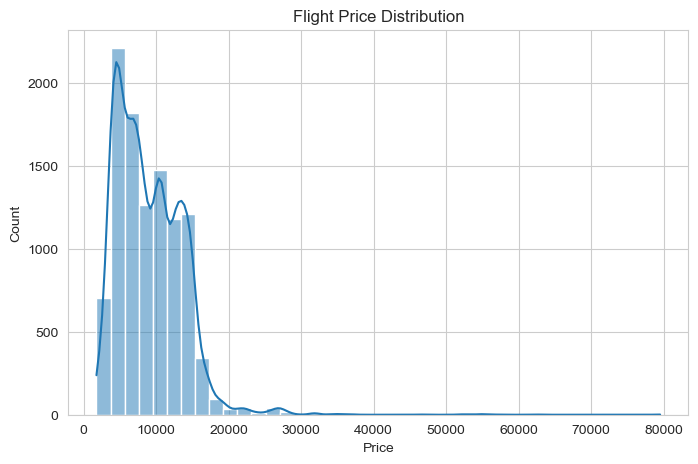

In [ ]:
# %% [10] EDA - Price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=40, kde=True)
plt.title('Flight Price Distribution')
plt.xlabel('Price')
plt.show()

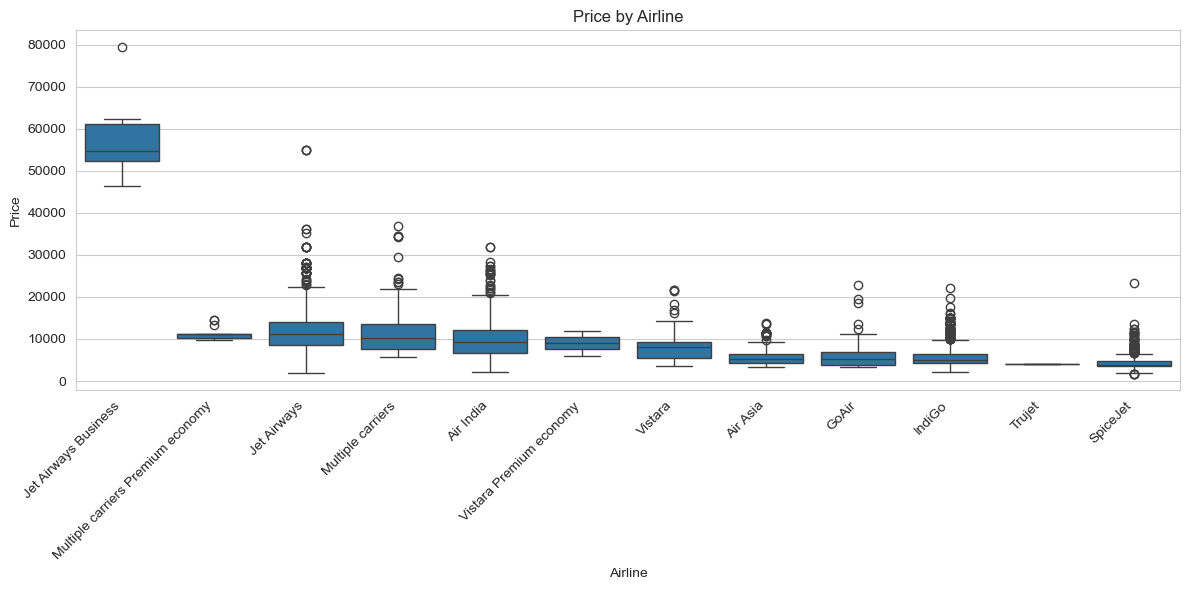

In [ ]:
# %% [11] EDA - Price by Airline
plt.figure(figsize=(12, 6))
order = df.groupby('Airline')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Airline', y='Price', order=order)
plt.xticks(rotation=45, ha='right')
plt.title('Price by Airline')
plt.tight_layout()
plt.show()

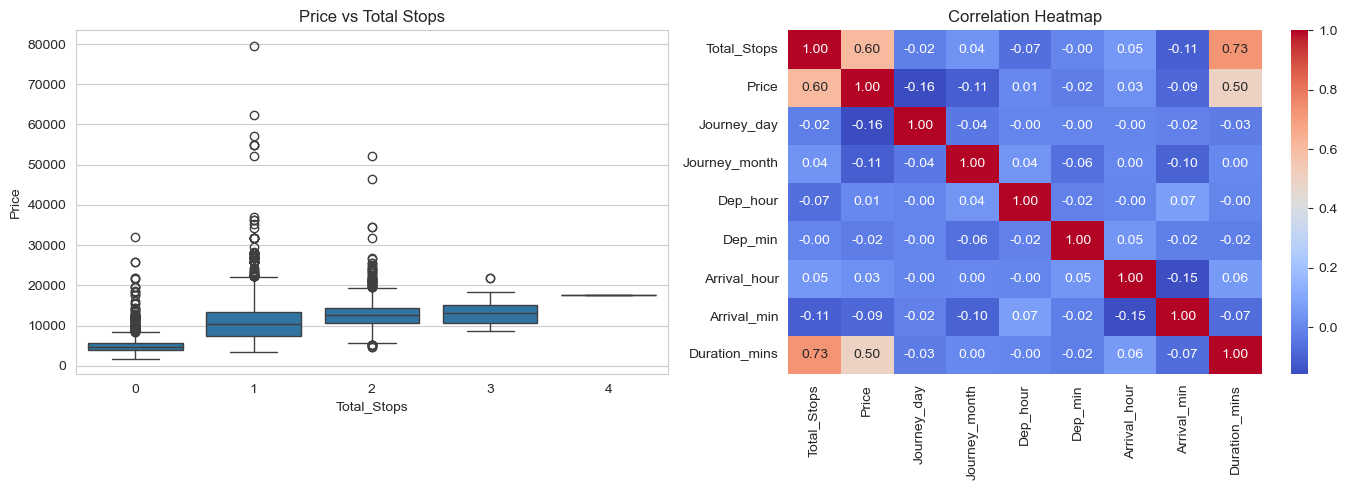

In [ ]:
# %% [12] EDA - Price vs number of stops, and correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.boxplot(data=df, x='Total_Stops', y='Price', ax=axes[0])
axes[0].set_title('Price vs Total Stops')
 
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap')
 
plt.tight_layout()
plt.show()

In [ ]:
# %% [13] Encode remaining categorical columns
# Airline, Source, Destination, Additional_Info are nominal (no natural order) -> one-hot encode
cat_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)
 
print("Final feature set shape:", df_model.shape)
df_model.columns.tolist()
 

Final feature set shape: (10462, 37)


['Total_Stops',
 'Price',
 'Journey_day',
 'Journey_month',
 'Dep_hour',
 'Dep_min',
 'Arrival_hour',
 'Arrival_min',
 'Duration_mins',
 'Airline_Air India',
 'Airline_GoAir',
 'Airline_IndiGo',
 'Airline_Jet Airways',
 'Airline_Jet Airways Business',
 'Airline_Multiple carriers',
 'Airline_Multiple carriers Premium economy',
 'Airline_SpiceJet',
 'Airline_Trujet',
 'Airline_Vistara',
 'Airline_Vistara Premium economy',
 'Source_Chennai',
 'Source_Delhi',
 'Source_Kolkata',
 'Source_Mumbai',
 'Destination_Cochin',
 'Destination_Delhi',
 'Destination_Hyderabad',
 'Destination_Kolkata',
 'Destination_New Delhi',
 'Additional_Info_1 Short layover',
 'Additional_Info_2 Long layover',
 'Additional_Info_Business class',
 'Additional_Info_Change airports',
 'Additional_Info_In-flight meal not included',
 'Additional_Info_No check-in baggage included',
 'Additional_Info_No info',
 'Additional_Info_Red-eye flight']

In [ ]:
# %% [14] Train / test split
from sklearn.model_selection import train_test_split
 
X = df_model.drop(columns=['Price'])
y = df_model['Price'] 
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (8369, 36) Test shape: (2093, 36)


In [ ]:
# %% [15] Baseline model - Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
 
print("R2 score :", r2_score(y_test, preds))
print("MAE      :", mean_absolute_error(y_test, preds))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, preds)))

R2 score : 0.89297070164652
MAE      : 674.3069044790614
RMSE     : 1493.8508798416335


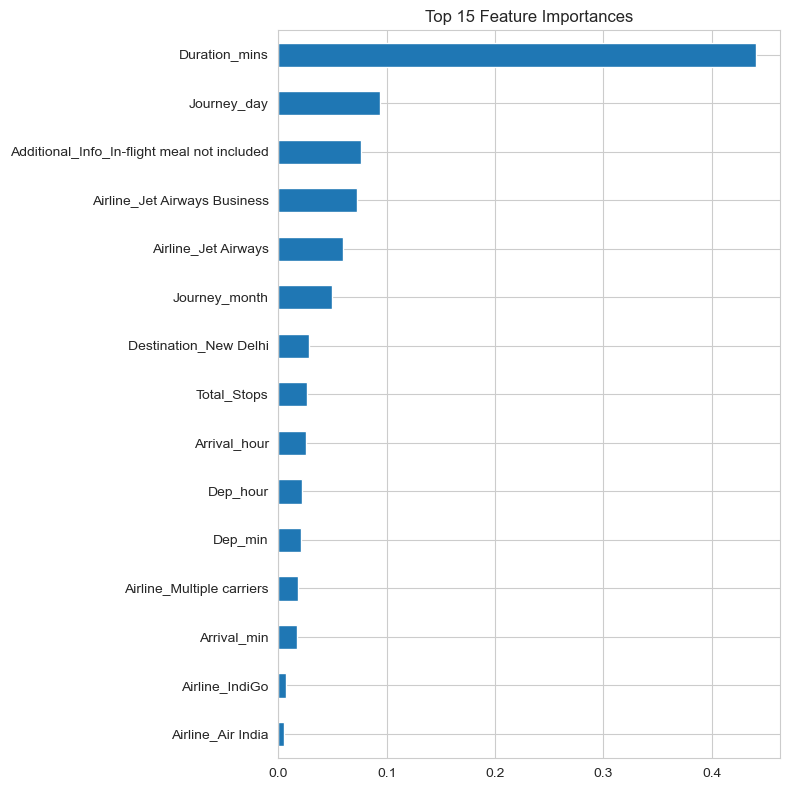

Duration_mins                                  0.441132
Journey_day                                    0.093857
Additional_Info_In-flight meal not included    0.075991
Airline_Jet Airways Business                   0.072276
Airline_Jet Airways                            0.059265
Journey_month                                  0.049582
Destination_New Delhi                          0.028376
Total_Stops                                    0.026589
Arrival_hour                                   0.025361
Dep_hour                                       0.021910
Dep_min                                        0.020996
Airline_Multiple carriers                      0.018037
Arrival_min                                    0.017073
Airline_IndiGo                                 0.006520
Airline_Air India                              0.004791
dtype: float64

In [ ]:
# %% [16] Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
 
plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()
 
importances.head(15)

In [ ]:
# %% [17] Hyperparameter tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
 
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
 
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='r2',
)
 
search.fit(X_train, y_train)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
# %% [18] Evaluate the tuned model
best_model = search.best_estimator_
tuned_preds = best_model.predict(X_test)
 
print("Tuned R2 score :", r2_score(y_test, tuned_preds))
print("Tuned MAE      :", mean_absolute_error(y_test, tuned_preds))
print("Tuned RMSE     :", np.sqrt(mean_squared_error(y_test, tuned_preds)))

Tuned R2 score : 0.8620916854658194
Tuned MAE      : 913.2556521225969
Tuned RMSE     : 1695.7082511001481


In [ ]:
# %% [19] Save the final model
import pickle
 
with open('flight_price_rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
 
# To reload later:
# with open('flight_price_rf_model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)
print("Model saved as flight_price_rf_model.pkl")
 


Model saved as flight_price_rf_model.pkl
